In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import joblibgit 

In [2]:
# Load Dataset
df = pd.read_csv("ml/sensor_Crop_Dataset.csv")

print("Dataset Loaded Successfully!\n")

print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
df.head()

Dataset Loaded Successfully!

Shape of Dataset:
(20000, 10)

Columns:
['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall', 'Crop', 'Soil_Type', 'Variety']

First 5 Rows:


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,83.563685,Sugarcane,Clay,Co 86032
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,31.508836,Sugarcane,Silt,Co 0238
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,295.193482,Maize,Sandy,Sweet


In [3]:
# ===============================
# Dataset Information
# ===============================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

display(df.head())

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nStatistical Summary:")
display(df.describe().T)

DATASET INFORMATION


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,83.563685,Sugarcane,Clay,Co 86032
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,31.508836,Sugarcane,Silt,Co 0238
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,295.193482,Maize,Sandy,Sweet



Shape of Dataset:
(20000, 10)

Column Names:
['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall', 'Crop', 'Soil_Type', 'Variety']

Data Types:


Nitrogen       float64
Phosphorus     float64
Potassium      float64
Temperature    float64
Humidity       float64
pH_Value       float64
Rainfall       float64
Crop            object
Soil_Type       object
Variety         object
dtype: object


Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Nitrogen,20000.0,77.216965,41.857663,5.006013,40.459715,77.573159,113.055595,149.998785
Phosphorus,20000.0,47.482070,24.587506,5.000483,26.225044,47.469579,68.625556,89.999086
Potassium,20000.0,55.162956,25.969091,10.000672,32.641905,55.248133,77.690183,99.996480
Temperature,20000.0,27.420717,10.010144,10.003760,18.880888,27.366450,35.997484,44.997407
Humidity,20000.0,64.897753,20.200687,30.002297,47.462026,64.776613,82.310482,99.992346
pH_Value,20000.0,6.496126,1.155750,4.500082,5.497988,6.493812,7.501771,8.499914
Rainfall,20000.0,211.124002,109.724973,20.018991,117.208556,211.263577,305.668849,399.974915


MISSING VALUES


,Missing Values,Percentage
Nitrogen,0,0.0
Phosphorus,0,0.0
Potassium,0,0.0
Temperature,0,0.0
Humidity,0,0.0
pH_Value,0,0.0
Rainfall,0,0.0
Crop,0,0.0
Soil_Type,0,0.0
Variety,0,0.0



Total Missing Values: 0

DUPLICATE RECORDS
Duplicate Rows: 0
No Duplicate Records Found.

CROP DISTRIBUTION


Crop
Wheat        3390
Potato       3362
Maize        3352
Tomato       3344
Sugarcane    3284
Rice         3268
Name: count, dtype: int64

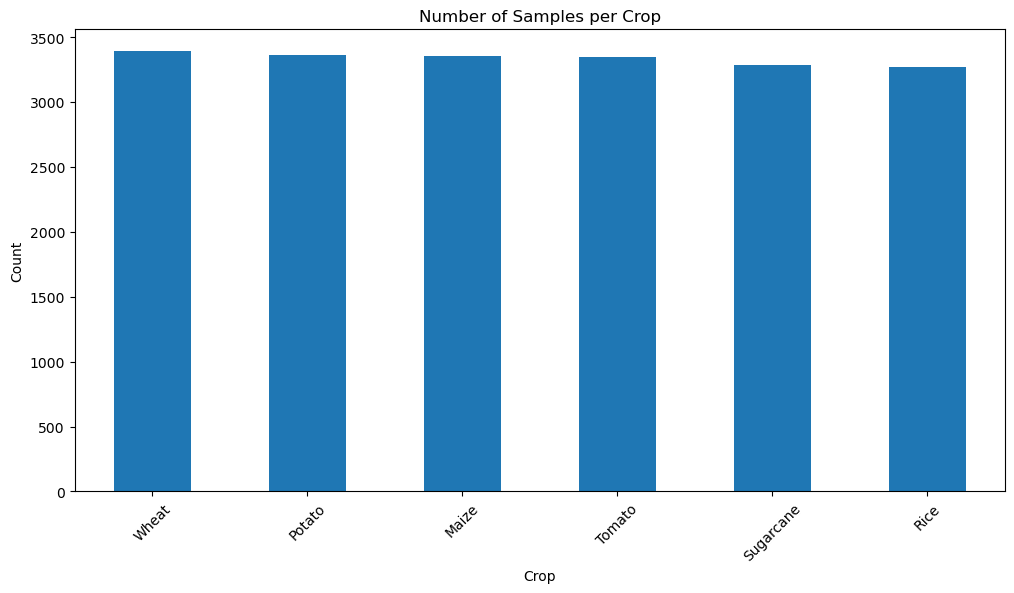

In [4]:
# ===============================
# Missing Values & Duplicate Check
# ===============================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()

display(pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df)) * 100
}))

print("\nTotal Missing Values:", missing.sum())

print("\n" + "=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates Removed Successfully!")
    print("New Shape:", df.shape)
else:
    print("No Duplicate Records Found.")

print("\n" + "=" * 60)
print("CROP DISTRIBUTION")
print("=" * 60)

display(df["Crop"].value_counts())

plt.figure(figsize=(12,6))
df["Crop"].value_counts().plot(kind="bar")
plt.title("Number of Samples per Crop")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

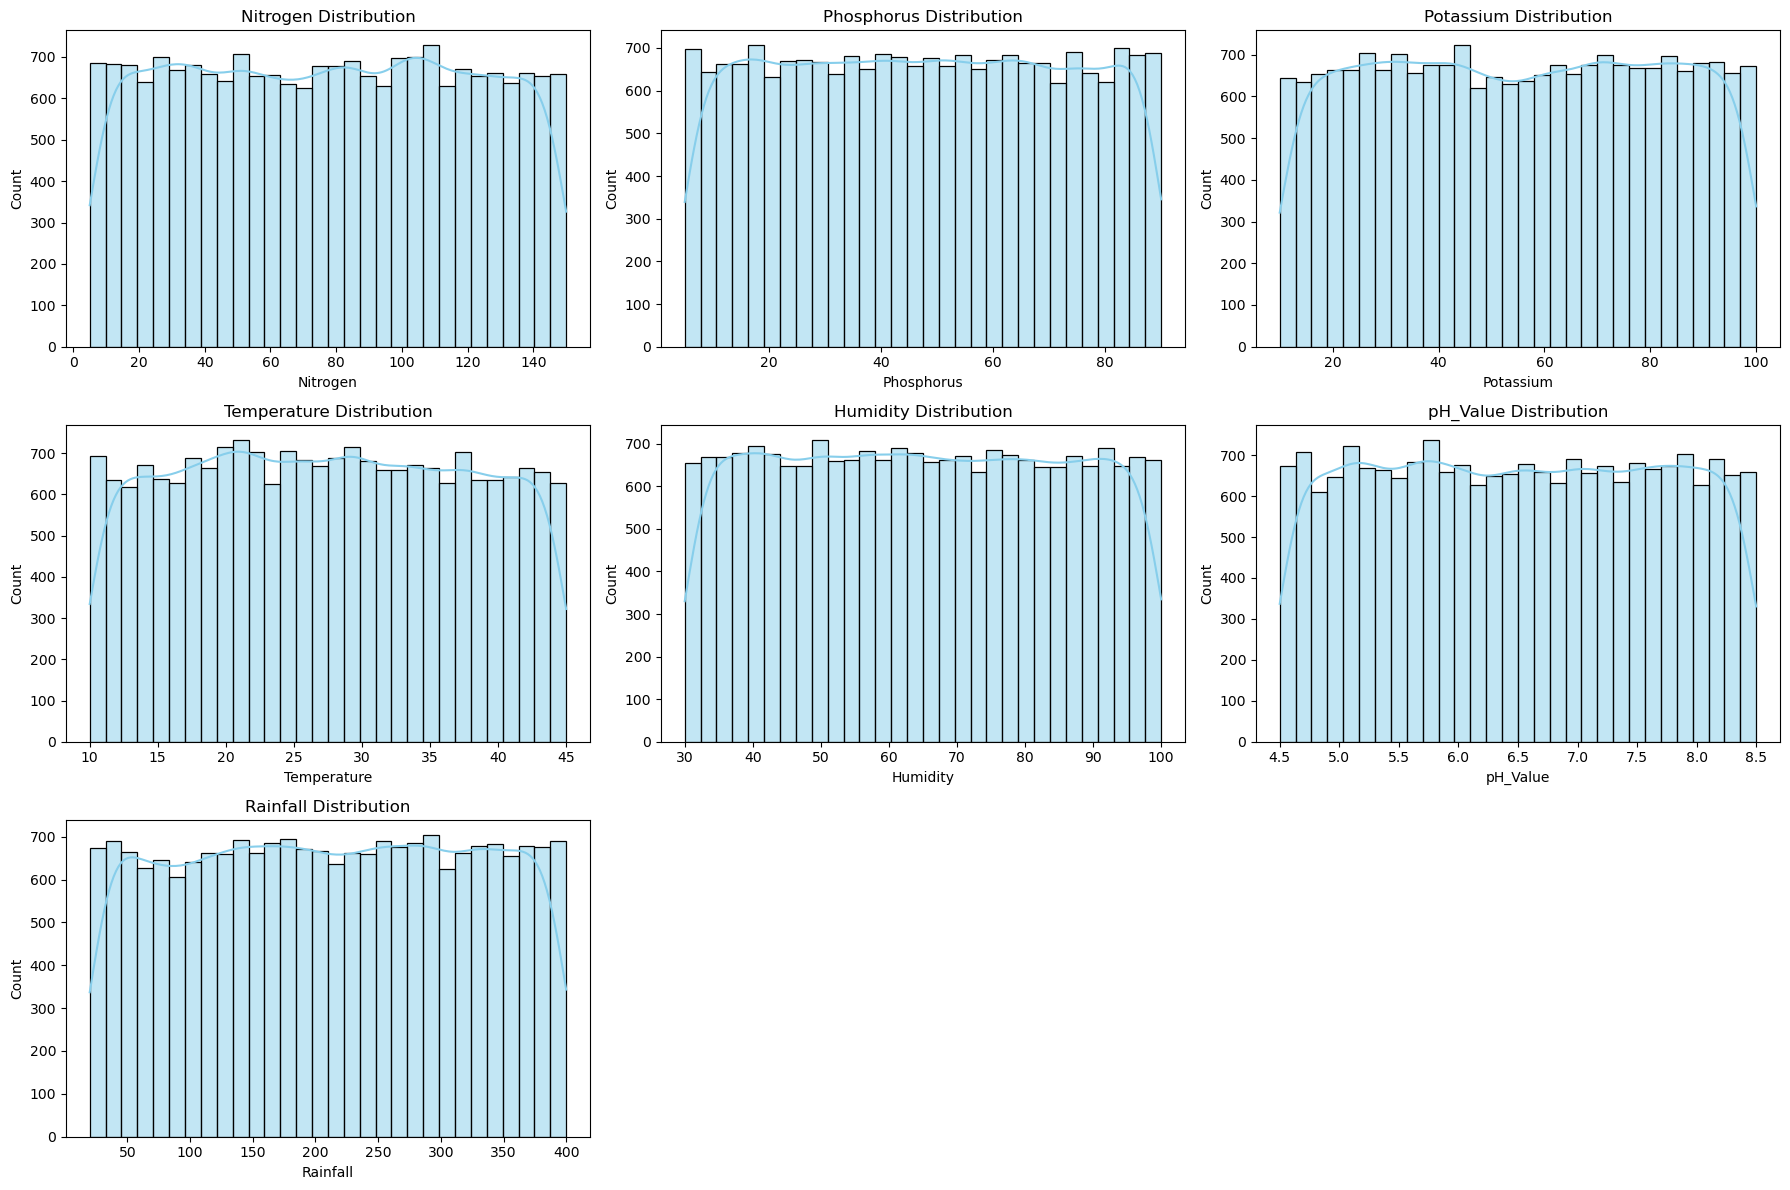

In [5]:
# ===============================
# Feature Distribution
# ===============================

features = [
    "Nitrogen",
    "Phosphorus",
    "Potassium",
    "Temperature",
    "Humidity",
    "pH_Value",
    "Rainfall"
]

plt.figure(figsize=(18,12))

for i, col in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col], bins=30, kde=True, color="skyblue")
    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

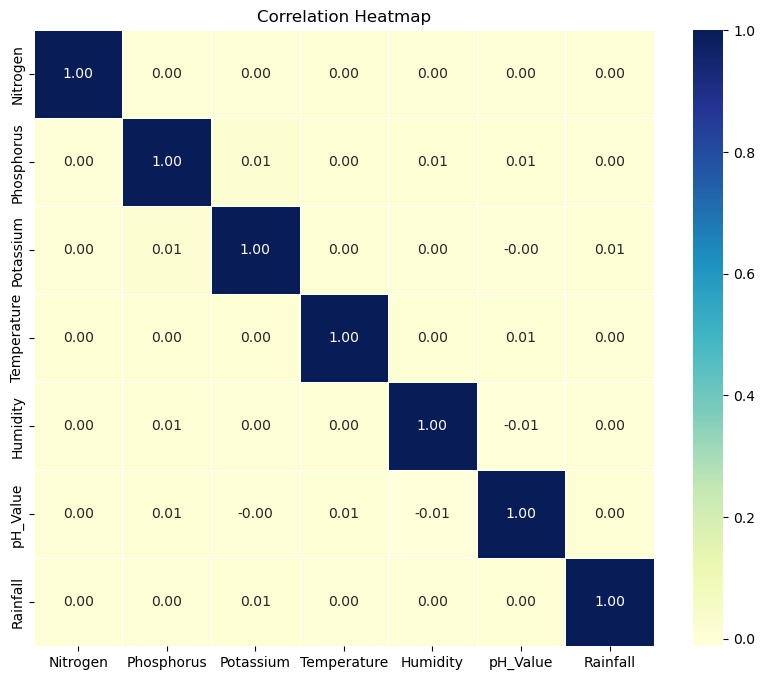

In [6]:
# ===============================
# Correlation Matrix
# ===============================

corr = df[[
    "Nitrogen",
    "Phosphorus",
    "Potassium",
    "Temperature",
    "Humidity",
    "pH_Value",
    "Rainfall"
]].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [7]:
# ==========================================
# Label Encoding & Feature Selection
# ==========================================

from sklearn.preprocessing import LabelEncoder

# Input Features
X = df[[
    "Nitrogen",
    "Phosphorus",
    "Potassium",
    "Temperature",
    "Humidity",
    "pH_Value",
    "Rainfall"
]]

# Target Variable
y = df["Crop"]

# Encode Crop Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("="*60)
print("Label Encoding Completed")
print("="*60)

print("\nNumber of Crop Classes :", len(label_encoder.classes_))

print("\nCrop Classes :")
print(label_encoder.classes_)

print("\nFeature Matrix Shape :", X.shape)
print("Target Shape :", y_encoded.shape)

Label Encoding Completed

Number of Crop Classes : 6

Crop Classes :
['Maize' 'Potato' 'Rice' 'Sugarcane' 'Tomato' 'Wheat']

Feature Matrix Shape : (20000, 7)
Target Shape : (20000,)


In [8]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("="*60)
print("Train-Test Split Completed")
print("="*60)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Train-Test Split Completed
Training Samples : 16000
Testing Samples  : 4000

Training Shape : (16000, 7)
Testing Shape  : (4000, 7)


In [9]:
# ==========================================
# Train XGBoost Model
# ==========================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),

    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,

    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0.1,
    reg_alpha=0,
    reg_lambda=1,

    random_state=42,
    eval_metric="mlogloss"
)

print("="*60)
print("Training XGBoost Model...")
print("="*60)

xgb_model.fit(X_train, y_train)

print("\n✅ Model Training Completed Successfully!")

Training XGBoost Model...

✅ Model Training Completed Successfully!


In [10]:
# ==========================================
# Model Evaluation
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
y_pred = xgb_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

print("\nClassification Report\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

MODEL PERFORMANCE
Accuracy : 17.18%
Precision: 17.16%
Recall   : 17.18%
F1 Score : 17.16%

Classification Report

              precision    recall  f1-score   support

       Maize       0.17      0.18      0.17       670
      Potato       0.17      0.17      0.17       672
        Rice       0.16      0.16      0.16       654
   Sugarcane       0.18      0.17      0.17       657
      Tomato       0.17      0.16      0.16       669
       Wheat       0.18      0.19      0.19       678

    accuracy                           0.17      4000
   macro avg       0.17      0.17      0.17      4000
weighted avg       0.17      0.17      0.17      4000



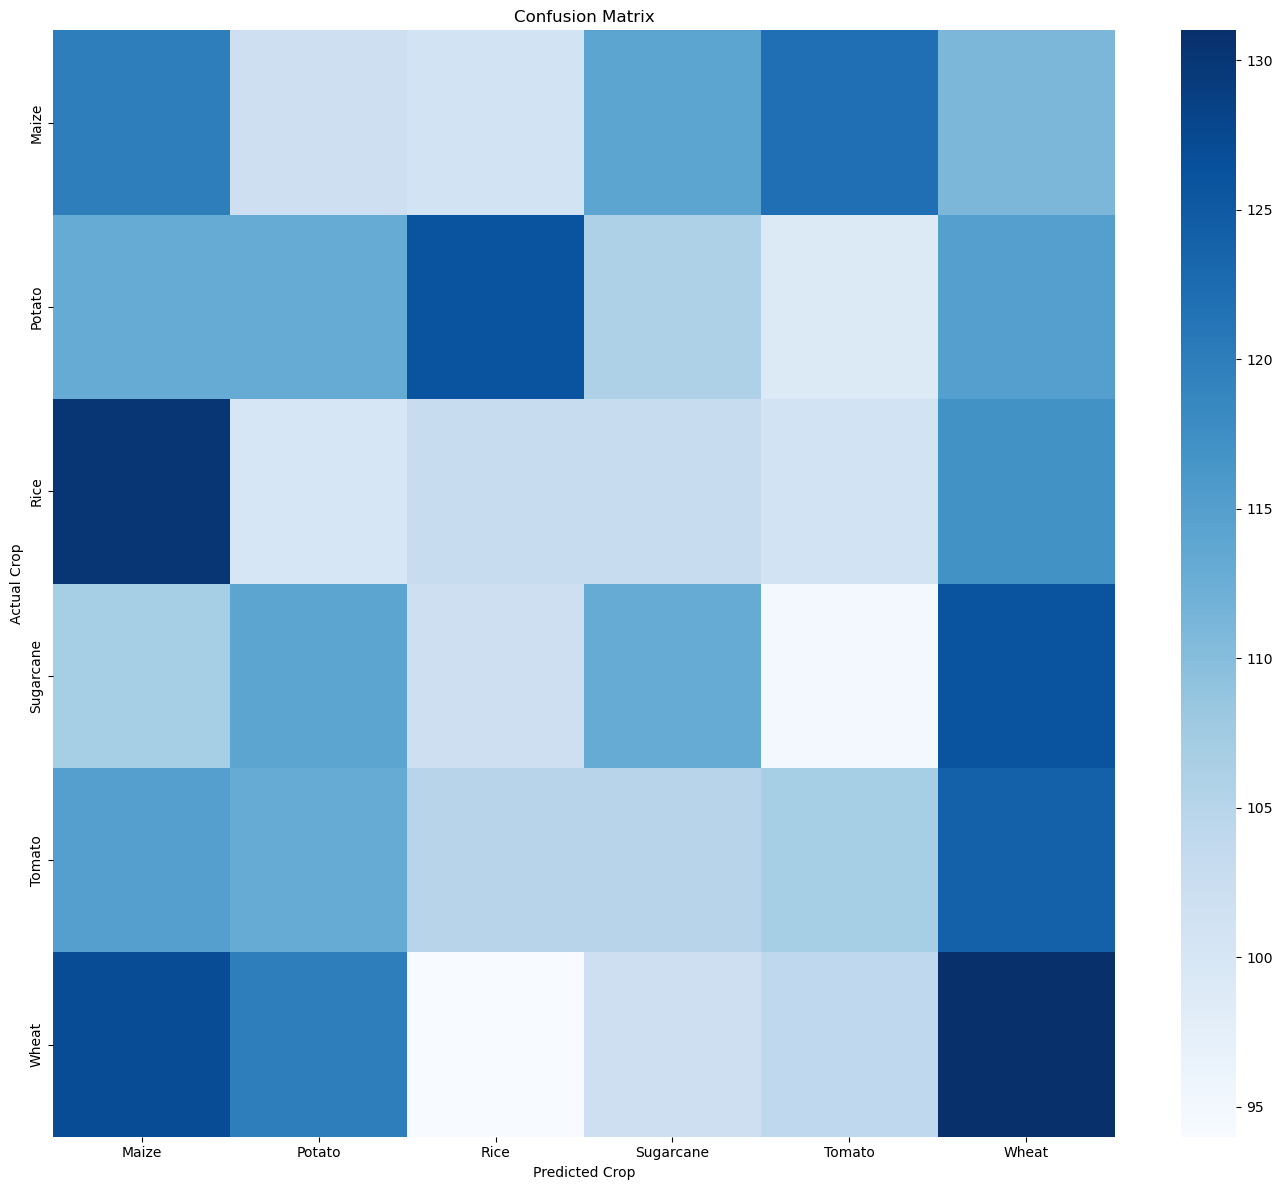

In [11]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    cmap="Blues",
    cbar=True,
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.tight_layout()
plt.show()

       Feature  Importance
2    Potassium    0.144029
6     Rainfall    0.143921
4     Humidity    0.143482
3  Temperature    0.142550
0     Nitrogen    0.142410
5     pH_Value    0.142173
1   Phosphorus    0.141435


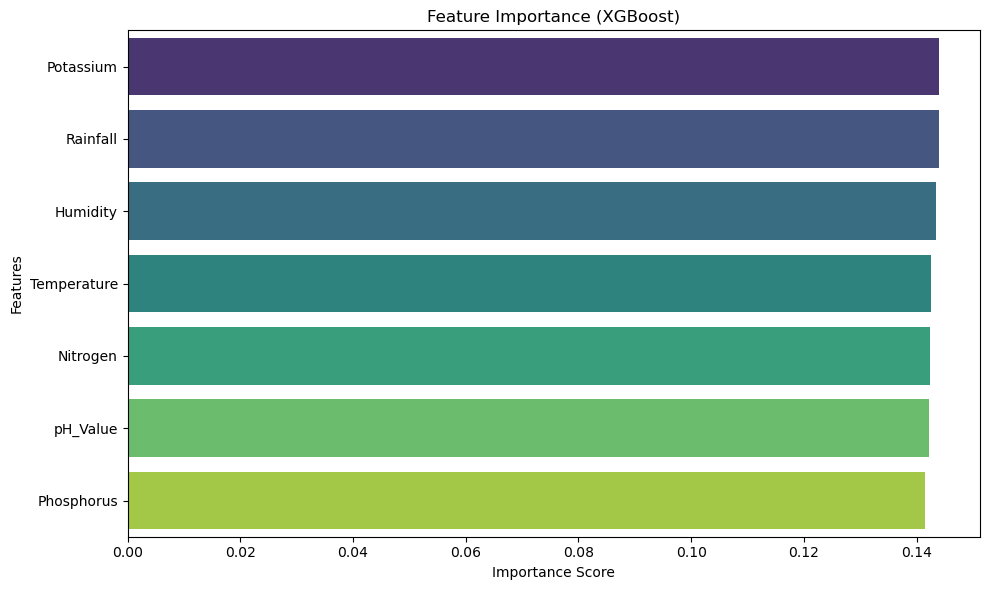

In [12]:
# ==========================================
# Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# Cross Validation
# ==========================================

from sklearn.model_selection import cross_val_score

print("="*60)
print("Performing 5-Fold Cross Validation...")
print("="*60)

scores = cross_val_score(
    xgb_model,
    X,
    y_encoded,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Accuracy: {:.2f}%".format(scores.mean()*100))
print("Standard Deviation: {:.4f}".format(scores.std()))

Performing 5-Fold Cross Validation...
Cross Validation Scores:
[0.171   0.15975 0.165   0.159   0.1505 ]

Average Accuracy: 16.11%
Standard Deviation: 0.0068


In [14]:
# ==========================================
# Save Model
# ==========================================

import joblib

joblib.dump(xgb_model, "xgboost_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("="*60)
print("Model Saved Successfully!")
print("="*60)

print("Saved Files:")
print("✔ xgboost_model.pkl")
print("✔ label_encoder.pkl")

Model Saved Successfully!
Saved Files:
✔ xgboost_model.pkl
✔ label_encoder.pkl


In [15]:
# ==========================================
# Test Prediction
# ==========================================

sample = np.array([
    [
        90,     # Nitrogen
        42,     # Phosphorus
        43,     # Potassium
        21.5,   # Temperature
        82.0,   # Humidity
        6.5,    # pH
        202.0   # Rainfall
    ]
])

prediction = xgb_model.predict(sample)

predicted_crop = label_encoder.inverse_transform(prediction)

probabilities = xgb_model.predict_proba(sample)[0]

top4 = np.argsort(probabilities)[-4:][::-1]

print("="*60)
print("Predicted Crop")
print("="*60)

print(predicted_crop[0])

print("\nTop 4 Recommendations")

for i in top4:
    print(
        f"{label_encoder.inverse_transform([i])[0]} : {probabilities[i]*100:.2f}%"
    )

Predicted Crop
Wheat

Top 4 Recommendations
Wheat : 21.02%
Potato : 17.84%
Rice : 17.83%
Sugarcane : 14.87%
